# AI-Powered Retail Demand Forecasting and Inventory Optimization

## Notebook 04 — Feature Engineering and ML Dataset Preparation

### Objective

The objective of this notebook is to transform the cleaned retail dataset into
a machine-learning-ready demand forecasting dataset.

The process includes:

- Calendar feature extraction
- Historical demand features
- Lag features
- Rolling statistics
- Business-related features
- Categorical feature preparation
- Target construction
- Time-based train/validation/test splitting
- Feature validation
- Saving the final ML datasets

### Important

All historical demand features must use information available before the
forecasted date.

Random train/test splitting will not be used because this is a time-series
forecasting problem.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
DATA_PATH = "../data/processed/cleaned_sales_data.csv"

df = pd.read_csv(DATA_PATH)

df["Date"] = pd.to_datetime(df["Date"])

print(f"Dataset shape: {df.shape}")

df.head()

Dataset shape: (76000, 16)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-02,S001,P0001,Electronics,North,93,71,0,65.63,5,Snowy,0,73.66,Winter,0,84
2,2022-01-03,S001,P0001,Electronics,North,274,142,229,68.55,15,Snowy,1,80.73,Winter,0,132
3,2022-01-04,S001,P0001,Electronics,North,132,42,0,61.66,10,Snowy,0,54.88,Winter,0,67
4,2022-01-05,S001,P0001,Electronics,North,319,129,0,59.56,25,Snowy,1,57.34,Winter,0,110


In [3]:
print("Dataset validation")
print("=" * 50)

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"Missing values: {df.isna().sum().sum():,}")
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Minimum date: {df['Date'].min()}")
print(f"Maximum date: {df['Date'].max()}")

Dataset validation
Rows: 76,000
Columns: 16
Missing values: 0
Duplicate rows: 0
Minimum date: 2022-01-01 00:00:00
Maximum date: 2024-01-30 00:00:00


In [4]:
df = df.sort_values(
    ["Store ID", "Product ID", "Date"]
).reset_index(drop=True)

df.head(10)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-02,S001,P0001,Electronics,North,93,71,0,65.63,5,Snowy,0,73.66,Winter,0,84
2,2022-01-03,S001,P0001,Electronics,North,274,142,229,68.55,15,Snowy,1,80.73,Winter,0,132
3,2022-01-04,S001,P0001,Electronics,North,132,42,0,61.66,10,Snowy,0,54.88,Winter,0,67
4,2022-01-05,S001,P0001,Electronics,North,319,129,0,59.56,25,Snowy,1,57.34,Winter,0,110
5,2022-01-06,S001,P0001,Electronics,North,190,98,308,84.03,0,Sunny,0,95.54,Winter,0,146
6,2022-01-07,S001,P0001,Electronics,North,92,92,0,66.07,10,Snowy,0,63.57,Winter,0,87
7,2022-01-08,S001,P0001,Electronics,North,308,96,248,68.56,10,Snowy,1,80.99,Winter,0,113
8,2022-01-09,S001,P0001,Electronics,North,212,57,0,62.76,10,Sunny,0,67.11,Winter,0,87
9,2022-01-10,S001,P0001,Electronics,North,403,88,0,68.99,5,Cloudy,0,81.14,Winter,0,99


## 1. Store-Product Time Series

Each combination of `Store ID` and `Product ID` represents an individual
demand time series.

Lag and rolling features will therefore be calculated independently for each
store-product combination.

In [5]:
GROUP_COLUMNS = [
    "Store ID",
    "Product ID"
]

print("Time-series grouping columns:")
print(GROUP_COLUMNS)

Time-series grouping columns:
['Store ID', 'Product ID']


## 2. Calendar Features

Calendar variables can capture recurring demand patterns.

We create:

- Year
- Month
- Quarter
- Day of month
- Day of week
- Weekend indicator

In [6]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter
df["DayOfMonth"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
df["IsWeekend"] = (
    df["DayOfWeek"] >= 5
).astype(int)

df[
    [
        "Date",
        "Year",
        "Month",
        "Quarter",
        "DayOfMonth",
        "DayOfWeek",
        "WeekOfYear",
        "IsWeekend"
    ]
].head()

,Date,Year,Month,Quarter,DayOfMonth,DayOfWeek,WeekOfYear,IsWeekend
0,2022-01-01,2022,1,1,1,5,52,1
1,2022-01-02,2022,1,1,2,6,52,1
2,2022-01-03,2022,1,1,3,0,1,0
3,2022-01-04,2022,1,1,4,1,1,0
4,2022-01-05,2022,1,1,5,2,1,0


## 3. Cyclical Calendar Features

Cyclical encoding represents periodic variables using sine and cosine
transformations.

This prevents the model from interpreting December and January as being
far apart.

In [7]:
# Day of week: 0-6
df["DayOfWeek_Sin"] = np.sin(
    2 * np.pi * df["DayOfWeek"] / 7
)

df["DayOfWeek_Cos"] = np.cos(
    2 * np.pi * df["DayOfWeek"] / 7
)

# Month: 1-12
df["Month_Sin"] = np.sin(
    2 * np.pi * (df["Month"] - 1) / 12
)

df["Month_Cos"] = np.cos(
    2 * np.pi * (df["Month"] - 1) / 12
)

df[
    [
        "DayOfWeek",
        "DayOfWeek_Sin",
        "DayOfWeek_Cos",
        "Month",
        "Month_Sin",
        "Month_Cos"
    ]
].head()

,DayOfWeek,DayOfWeek_Sin,DayOfWeek_Cos,Month,Month_Sin,Month_Cos
0,5,-0.974928,-0.222521,1,0.0,1.0
1,6,-0.781831,0.623490,1,0.0,1.0
2,0,0.000000,1.000000,1,0.0,1.0
3,1,0.781831,0.623490,1,0.0,1.0
4,2,0.974928,-0.222521,1,0.0,1.0


## 4. Historical Demand Features

Lag features represent historical demand.

For example:

- `Lag_1` = demand from the previous observation
- `Lag_7` = demand from seven observations ago
- `Lag_14` = demand from fourteen observations ago
- `Lag_30` = demand from thirty observations ago

These are calculated separately for each Store-Product combination.

### Important

Only historical demand is used.

The current day's `Demand` is never used to construct its own predictors.

In [8]:
LAG_PERIODS = [
    1,
    7,
    14,
    30
]

for lag in LAG_PERIODS:
    df[f"Lag_{lag}"] = (
        df.groupby(GROUP_COLUMNS)["Demand"]
        .shift(lag)
    )

print("Lag features created.")

df[
    [
        "Store ID",
        "Product ID",
        "Date",
        "Demand",
        "Lag_1",
        "Lag_7",
        "Lag_14",
        "Lag_30"
    ]
].head(20)

Lag features created.


,Store ID,Product ID,Date,Demand,Lag_1,Lag_7,Lag_14,Lag_30
0,S001,P0001,2022-01-01,115,NaN,NaN,NaN,NaN
1,S001,P0001,2022-01-02,84,115.0,NaN,NaN,NaN
2,S001,P0001,2022-01-03,132,84.0,NaN,NaN,NaN
3,S001,P0001,2022-01-04,67,132.0,NaN,NaN,NaN
4,S001,P0001,2022-01-05,110,67.0,NaN,NaN,NaN
5,S001,P0001,2022-01-06,146,110.0,NaN,NaN,NaN
6,S001,P0001,2022-01-07,87,146.0,NaN,NaN,NaN
7,S001,P0001,2022-01-08,113,87.0,115.0,NaN,NaN
8,S001,P0001,2022-01-09,87,113.0,84.0,NaN,NaN
9,S001,P0001,2022-01-10,99,87.0,132.0,NaN,NaN


## 5. Rolling Demand Features

Rolling averages capture recent demand behaviour.

We calculate:

- 7-observation rolling mean
- 14-observation rolling mean
- 30-observation rolling mean

The rolling window is shifted by one observation before calculation so that
the current target value is not included.

In [9]:
ROLLING_WINDOWS = [
    7,
    14,
    30
]

for window in ROLLING_WINDOWS:
    df[f"RollingMean_{window}"] = (
        df.groupby(GROUP_COLUMNS)["Demand"]
        .transform(
            lambda x: x.shift(1).rolling(window).mean()
        )
    )

print("Rolling mean features created.")

Rolling mean features created.


Rolling standard deviation captures recent demand volatility.

This is particularly useful for the inventory optimization component because
high demand variability may require higher safety stock.

In [10]:
for window in ROLLING_WINDOWS:
    df[f"RollingStd_{window}"] = (
        df.groupby(GROUP_COLUMNS)["Demand"]
        .transform(
            lambda x: x.shift(1).rolling(window).std()
        )
    )

print("Rolling standard deviation features created.")

Rolling standard deviation features created.


In [11]:
for window in [7, 30]:
    df[f"RollingMin_{window}"] = (
        df.groupby(GROUP_COLUMNS)["Demand"]
        .transform(
            lambda x: x.shift(1).rolling(window).min()
        )
    )

    df[f"RollingMax_{window}"] = (
        df.groupby(GROUP_COLUMNS)["Demand"]
        .transform(
            lambda x: x.shift(1).rolling(window).max()
        )
    )

print("Rolling minimum and maximum features created.")

Rolling minimum and maximum features created.


## 6. Historical Inventory Features

Current inventory may be available when making a forecast, depending on the
operational scenario.

To avoid ambiguity, we retain the current inventory level as a potential
feature and also create lagged inventory features.

The final feature selection will be determined during model development.

In [12]:
for lag in [1, 7]:
    df[f"Inventory_Lag_{lag}"] = (
        df.groupby(GROUP_COLUMNS)["Inventory Level"]
        .shift(lag)
    )

print("Historical inventory features created.")

Historical inventory features created.


## 7. Historical Sales Features

`Units Sold` may be strongly related to realized demand.

Therefore, the current value is potentially problematic as a forecasting
predictor.

Historical units sold can still provide useful information because they are
known before the future forecast period.

In [13]:
for lag in [1, 7, 14]:
    df[f"UnitsSold_Lag_{lag}"] = (
        df.groupby(GROUP_COLUMNS)["Units Sold"]
        .shift(lag)
    )

print("Historical sales features created.")

Historical sales features created.


In [14]:
for lag in [1, 7, 14]:
    df[f"UnitsOrdered_Lag_{lag}"] = (
        df.groupby(GROUP_COLUMNS)["Units Ordered"]
        .shift(lag)
    )

print("Historical order features created.")

Historical order features created.


## 8. Price Features

Price can influence demand.

We retain the current price and calculate historical price changes.

In [15]:
df["Price_Lag_1"] = (
    df.groupby(GROUP_COLUMNS)["Price"]
    .shift(1)
)

df["Price_Change"] = (
    df["Price"] - df["Price_Lag_1"]
)

df["Price_Change_Pct"] = (
    df["Price_Change"] /
    df["Price_Lag_1"].replace(0, np.nan)
)

df[
    [
        "Price",
        "Price_Lag_1",
        "Price_Change",
        "Price_Change_Pct"
    ]
].head()

,Price,Price_Lag_1,Price_Change,Price_Change_Pct
0,72.72,NaN,NaN,NaN
1,65.63,72.72,-7.09,-0.097497
2,68.55,65.63,2.92,0.044492
3,61.66,68.55,-6.89,-0.100511
4,59.56,61.66,-2.10,-0.034058


In [16]:
df["CompetitorPrice_Lag_1"] = (
    df.groupby(GROUP_COLUMNS)["Competitor Pricing"]
    .shift(1)
)

df["CompetitorPrice_Change"] = (
    df["Competitor Pricing"] -
    df["CompetitorPrice_Lag_1"]
)

df["Price_Competitor_Difference"] = (
    df["Price"] -
    df["Competitor Pricing"]
)

df[
    [
        "Price",
        "Competitor Pricing",
        "Price_Competitor_Difference",
        "CompetitorPrice_Change"
    ]
].head()

,Price,Competitor Pricing,Price_Competitor_Difference,CompetitorPrice_Change
0,72.72,85.73,-13.01,NaN
1,65.63,73.66,-8.03,-12.07
2,68.55,80.73,-12.18,7.07
3,61.66,54.88,6.78,-25.85
4,59.56,57.34,2.22,2.46


## 9. Inventory Position Features

These variables describe the relationship between historical demand and
inventory.

They may later be useful for the inventory optimization component.

In [17]:
df["Inventory_Demand_Ratio"] = (
    df["Inventory Level"] /
    df["Lag_7"].replace(0, np.nan)
)

df["Inventory_Coverage_Approx"] = (
    df["Inventory Level"] /
    df["RollingMean_7"].replace(0, np.nan)
)

df[
    [
        "Inventory Level",
        "Lag_7",
        "RollingMean_7",
        "Inventory_Demand_Ratio",
        "Inventory_Coverage_Approx"
    ]
].head()

,Inventory Level,Lag_7,RollingMean_7,Inventory_Demand_Ratio,Inventory_Coverage_Approx
0,195,NaN,NaN,NaN,NaN
1,93,NaN,NaN,NaN,NaN
2,274,NaN,NaN,NaN,NaN
3,132,NaN,NaN,NaN,NaN
4,319,NaN,NaN,NaN,NaN


## 10. Target Variable

The target variable is:

`Demand`

The model will learn to predict demand using historical information and
available business/contextual variables.

In [18]:
TARGET = "Demand"

print(f"Target variable: {TARGET}")

Target variable: Demand


In [19]:
feature_history_columns = [
    "Lag_30",
    "RollingMean_30",
    "RollingStd_30"
]

before_rows = len(df)

df_model = df.dropna(
    subset=feature_history_columns
).copy()

after_rows = len(df_model)

print(f"Rows before history filtering: {before_rows:,}")
print(f"Rows after history filtering : {after_rows:,}")
print(f"Rows removed                 : {before_rows - after_rows:,}")

Rows before history filtering: 76,000
Rows after history filtering : 73,000
Rows removed                 : 3,000


In [20]:
missing_features = (
    df_model.isna().sum()
    .sort_values(ascending=False)
)

missing_features[
    missing_features > 0
]

Series([], dtype: int64)

In [21]:
df_model = df_model.replace(
    [np.inf, -np.inf],
    np.nan
)

print("Infinite values replaced with NaN.")

Infinite values replaced with NaN.


In [22]:
print("Feature-engineered dataset")
print("=" * 50)

print(f"Rows    : {len(df_model):,}")
print(f"Columns : {len(df_model.columns)}")

Feature-engineered dataset
Rows    : 73,000
Columns : 57


In [23]:
for i, column in enumerate(
    df_model.columns,
    start=1
):
    print(f"{i:03d}. {column}")

001. Date
002. Store ID
003. Product ID
004. Category
005. Region
006. Inventory Level
007. Units Sold
008. Units Ordered
009. Price
010. Discount
011. Weather Condition
012. Promotion
013. Competitor Pricing
014. Seasonality
015. Epidemic
016. Demand
017. Year
018. Month
019. Quarter
020. DayOfMonth
021. DayOfWeek
022. WeekOfYear
023. IsWeekend
024. DayOfWeek_Sin
025. DayOfWeek_Cos
026. Month_Sin
027. Month_Cos
028. Lag_1
029. Lag_7
030. Lag_14
031. Lag_30
032. RollingMean_7
033. RollingMean_14
034. RollingMean_30
035. RollingStd_7
036. RollingStd_14
037. RollingStd_30
038. RollingMin_7
039. RollingMax_7
040. RollingMin_30
041. RollingMax_30
042. Inventory_Lag_1
043. Inventory_Lag_7
044. UnitsSold_Lag_1
045. UnitsSold_Lag_7
046. UnitsSold_Lag_14
047. UnitsOrdered_Lag_1
048. UnitsOrdered_Lag_7
049. UnitsOrdered_Lag_14
050. Price_Lag_1
051. Price_Change
052. Price_Change_Pct
053. CompetitorPrice_Lag_1
054. CompetitorPrice_Change
055. Price_Competitor_Difference
056. Inventory_Demand_Rat

## 11. Initial Feature Set

The initial feature set contains:

### Calendar features
- Year
- Month
- Quarter
- DayOfMonth
- DayOfWeek
- WeekOfYear
- IsWeekend
- Cyclical calendar features

### Historical demand
- Lag features
- Rolling mean
- Rolling standard deviation
- Rolling minimum
- Rolling maximum

### Historical business variables
- Historical inventory
- Historical sales
- Historical orders
- Historical price
- Competitor pricing history

### Current business/context variables
- Price
- Discount
- Promotion
- Weather
- Seasonality
- Region
- Inventory

Some features will be removed or modified during model training if they are
found to introduce leakage or are unavailable at forecast time.

In [24]:
categorical_features = [
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Promotion",
    "Seasonality",
    "Epidemic"
]

categorical_features

['Store ID',
 'Product ID',
 'Category',
 'Region',
 'Weather Condition',
 'Promotion',
 'Seasonality',
 'Epidemic']

In [25]:
excluded_columns = [
    "Date",
    TARGET
]

numerical_features = [
    column
    for column in df_model.columns
    if column not in categorical_features
    and column not in excluded_columns
]

print(f"Numerical features: {len(numerical_features)}")

numerical_features

Numerical features: 47


['Inventory Level',
 'Units Sold',
 'Units Ordered',
 'Price',
 'Discount',
 'Competitor Pricing',
 'Year',
 'Month',
 'Quarter',
 'DayOfMonth',
 'DayOfWeek',
 'WeekOfYear',
 'IsWeekend',
 'DayOfWeek_Sin',
 'DayOfWeek_Cos',
 'Month_Sin',
 'Month_Cos',
 'Lag_1',
 'Lag_7',
 'Lag_14',
 'Lag_30',
 'RollingMean_7',
 'RollingMean_14',
 'RollingMean_30',
 'RollingStd_7',
 'RollingStd_14',
 'RollingStd_30',
 'RollingMin_7',
 'RollingMax_7',
 'RollingMin_30',
 'RollingMax_30',
 'Inventory_Lag_1',
 'Inventory_Lag_7',
 'UnitsSold_Lag_1',
 'UnitsSold_Lag_7',
 'UnitsSold_Lag_14',
 'UnitsOrdered_Lag_1',
 'UnitsOrdered_Lag_7',
 'UnitsOrdered_Lag_14',
 'Price_Lag_1',
 'Price_Change',
 'Price_Change_Pct',
 'CompetitorPrice_Lag_1',
 'CompetitorPrice_Change',
 'Price_Competitor_Difference',
 'Inventory_Demand_Ratio',
 'Inventory_Coverage_Approx']

## 12. Leakage Check

We explicitly inspect features that could contain information about the target
that would not be available at forecasting time.

Current-day `Units Sold` and current-day `Units Ordered` are excluded from the
initial feature set because they may represent information generated after or
alongside actual demand.

Historical versions are retained because they represent information available
before the forecast date.

In [26]:
model_features = [
    # Calendar
    "Year",
    "Month",
    "Quarter",
    "DayOfMonth",
    "DayOfWeek",
    "WeekOfYear",
    "IsWeekend",
    "DayOfWeek_Sin",
    "DayOfWeek_Cos",
    "Month_Sin",
    "Month_Cos",

    # Historical demand
    "Lag_1",
    "Lag_7",
    "Lag_14",
    "Lag_30",
    "RollingMean_7",
    "RollingMean_14",
    "RollingMean_30",
    "RollingStd_7",
    "RollingStd_14",
    "RollingStd_30",
    "RollingMin_7",
    "RollingMax_7",
    "RollingMin_30",
    "RollingMax_30",

    # Historical inventory
    "Inventory_Lag_1",
    "Inventory_Lag_7",

    # Historical sales
    "UnitsSold_Lag_1",
    "UnitsSold_Lag_7",
    "UnitsSold_Lag_14",

    # Historical orders
    "UnitsOrdered_Lag_1",
    "UnitsOrdered_Lag_7",
    "UnitsOrdered_Lag_14",

    # Current business variables
    "Inventory Level",
    "Price",
    "Discount",
    "Competitor Pricing",

    # Price-related
    "Price_Lag_1",
    "Price_Change",
    "Price_Change_Pct",
    "CompetitorPrice_Lag_1",
    "CompetitorPrice_Change",
    "Price_Competitor_Difference",

    # Inventory-related
    "Inventory_Demand_Ratio",
    "Inventory_Coverage_Approx",

    # Categorical
    "Store ID",
    "Product ID",
    "Category",
    "Region",
    "Weather Condition",
    "Promotion",
    "Seasonality",
    "Epidemic"
]

print(f"Number of model features: {len(model_features)}")

Number of model features: 53


In [27]:
missing_model_features = [
    feature
    for feature in model_features
    if feature not in df_model.columns
]

if missing_model_features:
    print("Missing features:")
    print(missing_model_features)
else:
    print("All model features exist.")

All model features exist.


In [28]:
model_df = df_model[
    [
        "Date",
        *model_features,
        TARGET
    ]
].copy()

print(f"Model dataset shape: {model_df.shape}")

model_df.head()

Model dataset shape: (73000, 55)


,Date,Year,Month,Quarter,DayOfMonth,DayOfWeek,WeekOfYear,IsWeekend,DayOfWeek_Sin,DayOfWeek_Cos,Month_Sin,Month_Cos,Lag_1,Lag_7,Lag_14,Lag_30,RollingMean_7,RollingMean_14,RollingMean_30,RollingStd_7,RollingStd_14,RollingStd_30,RollingMin_7,RollingMax_7,RollingMin_30,RollingMax_30,Inventory_Lag_1,Inventory_Lag_7,UnitsSold_Lag_1,UnitsSold_Lag_7,UnitsSold_Lag_14,UnitsOrdered_Lag_1,UnitsOrdered_Lag_7,UnitsOrdered_Lag_14,Inventory Level,Price,Discount,Competitor Pricing,Price_Lag_1,Price_Change,Price_Change_Pct,CompetitorPrice_Lag_1,CompetitorPrice_Change,Price_Competitor_Difference,Inventory_Demand_Ratio,Inventory_Coverage_Approx,Store ID,Product ID,Category,Region,Weather Condition,Promotion,Seasonality,Epidemic,Demand
30,2022-01-31,2022,1,1,31,0,5,0,0.000000,1.000000,0.0,1.000000,79.0,44.0,102.0,115.0,100.857143,98.285714,101.133333,54.861731,43.822068,36.977844,44.0,194.0,25.0,194.0,537.0,181.0,73.0,29.0,73.0,0.0,0.0,0.0,464,72.10,10,70.23,71.59,0.51,0.007124,69.69,0.54,1.87,10.545455,4.600567,S001,P0001,Electronics,North,Cloudy,0,Winter,0,113
31,2022-02-01,2022,2,1,1,1,5,0,0.781831,0.623490,0.5,0.866025,113.0,61.0,102.0,84.0,110.714286,99.071429,101.066667,48.808177,43.992070,36.953777,61.0,194.0,25.0,194.0,464.0,428.0,103.0,55.0,101.0,0.0,0.0,0.0,361,70.53,5,66.56,72.10,-1.57,-0.021775,70.23,-3.67,3.97,5.918033,3.260645,S001,P0001,Electronics,North,Snowy,0,Winter,0,90
32,2022-02-02,2022,2,1,2,2,5,0,0.974928,-0.222521,0.5,0.866025,90.0,160.0,123.0,132.0,114.857143,98.214286,101.266667,44.964536,44.047489,36.874375,79.0,194.0,25.0,194.0,361.0,373.0,102.0,147.0,103.0,0.0,331.0,0.0,259,60.16,20,54.96,70.53,-10.37,-0.147030,66.56,-11.60,5.20,1.618750,2.254975,S001,P0001,Electronics,North,Cloudy,1,Winter,0,94
33,2022-02-03,2022,2,1,3,3,5,0,0.433884,-0.900969,0.5,0.866025,94.0,87.0,25.0,67.0,105.428571,96.142857,100.000000,40.631913,43.470339,36.432271,79.0,194.0,25.0,194.0,259.0,226.0,94.0,93.0,20.0,215.0,0.0,0.0,165,64.73,5,56.97,60.16,4.57,0.075964,54.96,2.01,7.76,1.896552,1.565041,S001,P0001,Electronics,North,Cloudy,0,Winter,0,66
34,2022-02-04,2022,2,1,4,4,5,0,-0.433884,-0.900969,0.5,0.866025,66.0,194.0,90.0,110.0,102.428571,99.071429,99.966667,42.929621,39.509423,36.463949,66.0,194.0,25.0,194.0,165.0,464.0,41.0,201.0,92.0,0.0,343.0,0.0,339,69.70,10,81.05,64.73,4.97,0.076780,56.97,24.08,-11.35,1.747423,3.309623,S001,P0001,Electronics,North,Snowy,1,Winter,0,119


In [29]:
before = len(model_df)

model_df = model_df.dropna(
    subset=model_features + [TARGET]
).reset_index(drop=True)

after = len(model_df)

print(f"Rows before removing missing features: {before:,}")
print(f"Rows after removing missing features : {after:,}")
print(f"Rows removed                         : {before - after:,}")

Rows before removing missing features: 73,000
Rows after removing missing features : 73,000
Rows removed                         : 0


In [30]:
model_df = model_df.sort_values(
    ["Date", "Store ID", "Product ID"]
).reset_index(drop=True)

model_df.head()

,Date,Year,Month,Quarter,DayOfMonth,DayOfWeek,WeekOfYear,IsWeekend,DayOfWeek_Sin,DayOfWeek_Cos,Month_Sin,Month_Cos,Lag_1,Lag_7,Lag_14,Lag_30,RollingMean_7,RollingMean_14,RollingMean_30,RollingStd_7,RollingStd_14,RollingStd_30,RollingMin_7,RollingMax_7,RollingMin_30,RollingMax_30,Inventory_Lag_1,Inventory_Lag_7,UnitsSold_Lag_1,UnitsSold_Lag_7,UnitsSold_Lag_14,UnitsOrdered_Lag_1,UnitsOrdered_Lag_7,UnitsOrdered_Lag_14,Inventory Level,Price,Discount,Competitor Pricing,Price_Lag_1,Price_Change,Price_Change_Pct,CompetitorPrice_Lag_1,CompetitorPrice_Change,Price_Competitor_Difference,Inventory_Demand_Ratio,Inventory_Coverage_Approx,Store ID,Product ID,Category,Region,Weather Condition,Promotion,Seasonality,Epidemic,Demand
0,2022-01-31,2022,1,1,31,0,5,0,0.0,1.0,0.0,1.0,79.0,44.0,102.0,115.0,100.857143,98.285714,101.133333,54.861731,43.822068,36.977844,44.0,194.0,25.0,194.0,537.0,181.0,73.0,29.0,73.0,0.0,0.0,0.0,464,72.10,10,70.23,71.59,0.51,0.007124,69.69,0.54,1.87,10.545455,4.600567,S001,P0001,Electronics,North,Cloudy,0,Winter,0,113
1,2022-01-31,2022,1,1,31,0,5,0,0.0,1.0,0.0,1.0,122.0,136.0,246.0,229.0,123.428571,145.500000,151.966667,31.304191,54.555194,46.939788,87.0,176.0,83.0,246.0,230.0,167.0,121.0,109.0,112.0,0.0,123.0,276.0,109,65.64,5,61.62,64.01,1.63,0.025465,76.27,-14.65,4.02,0.801471,0.883102,S001,P0002,Clothing,North,Cloudy,0,Winter,0,97
2,2022-01-31,2022,1,1,31,0,5,0,0.0,1.0,0.0,1.0,136.0,83.0,203.0,157.0,132.571429,145.928571,139.866667,40.582661,43.428924,40.932858,83.0,208.0,71.0,224.0,885.0,568.0,83.0,77.0,236.0,0.0,0.0,0.0,802,65.92,10,60.55,62.50,3.42,0.054720,58.53,2.02,5.37,9.662651,6.049569,S001,P0003,Clothing,North,Cloudy,0,Winter,0,175
3,2022-01-31,2022,1,1,31,0,5,0,0.0,1.0,0.0,1.0,77.0,86.0,45.0,52.0,98.857143,93.857143,85.733333,27.504112,27.883983,31.989150,75.0,144.0,31.0,144.0,140.0,114.0,65.0,53.0,31.0,0.0,149.0,0.0,383,112.46,0,103.15,101.42,11.04,0.108854,118.16,-15.01,9.31,4.453488,3.874277,S001,P0004,Electronics,North,Cloudy,0,Winter,0,92
4,2022-01-31,2022,1,1,31,0,5,0,0.0,1.0,0.0,1.0,40.0,124.0,147.0,59.0,107.285714,120.428571,120.100000,58.360130,52.690262,42.819871,40.0,200.0,40.0,205.0,1005.0,199.0,27.0,114.0,94.0,0.0,0.0,0.0,978,58.88,0,53.60,45.47,13.41,0.294920,40.67,12.93,5.28,7.887097,9.115846,S001,P0005,Groceries,North,Cloudy,0,Winter,0,81


## 13. Time-Based Train / Validation / Test Split

Because this is a demand forecasting problem, random splitting is avoided.

The model must learn from the past and predict the future.

We therefore split the dataset chronologically:

- 70% → Training
- 15% → Validation
- 15% → Testing

The exact dates are determined from the dataset rather than randomly selected.

In [31]:
unique_dates = np.sort(
    model_df["Date"].unique()
)

n_dates = len(unique_dates)

train_end_index = int(n_dates * 0.70)
validation_end_index = int(n_dates * 0.85)

train_end_date = unique_dates[
    train_end_index - 1
]

validation_end_date = unique_dates[
    validation_end_index - 1
]

test_start_date = unique_dates[
    validation_end_index
]

print(f"Training ends      : {train_end_date}")
print(f"Validation ends    : {validation_end_date}")
print(f"Testing starts     : {test_start_date}")

Training ends      : 2023-06-24T00:00:00.000000000
Validation ends    : 2023-10-12T00:00:00.000000000
Testing starts     : 2023-10-13T00:00:00.000000000


In [32]:
train_df = model_df[
    model_df["Date"] <= train_end_date
].copy()

validation_df = model_df[
    (model_df["Date"] > train_end_date) &
    (model_df["Date"] <= validation_end_date)
].copy()

test_df = model_df[
    model_df["Date"] > validation_end_date
].copy()

print("Dataset split:")
print("=" * 50)

print(f"Training   : {len(train_df):,}")
print(f"Validation : {len(validation_df):,}")
print(f"Testing    : {len(test_df):,}")

Dataset split:
Training   : 51,000
Validation : 11,000
Testing    : 11,000


In [33]:
print("TRAIN")
print(train_df["Date"].min(), "→", train_df["Date"].max())

print("\nVALIDATION")
print(validation_df["Date"].min(), "→", validation_df["Date"].max())

print("\nTEST")
print(test_df["Date"].min(), "→", test_df["Date"].max())

TRAIN
2022-01-31 00:00:00 → 2023-06-24 00:00:00

VALIDATION
2023-06-25 00:00:00 → 2023-10-12 00:00:00

TEST
2023-10-13 00:00:00 → 2024-01-30 00:00:00


In [34]:
assert train_df["Date"].max() < validation_df["Date"].min()
assert validation_df["Date"].max() < test_df["Date"].min()

print("Chronological split verified successfully.")

Chronological split verified successfully.


In [35]:
split_summary = pd.DataFrame({
    "Dataset": [
        "Train",
        "Validation",
        "Test"
    ],
    "Rows": [
        len(train_df),
        len(validation_df),
        len(test_df)
    ],
    "Average Demand": [
        train_df["Demand"].mean(),
        validation_df["Demand"].mean(),
        test_df["Demand"].mean()
    ],
    "Demand Std": [
        train_df["Demand"].std(),
        validation_df["Demand"].std(),
        test_df["Demand"].std()
    ]
})

split_summary

,Dataset,Rows,Average Demand,Demand Std
0,Train,51000,103.114510,47.077084
1,Validation,11000,112.674182,48.472427
2,Test,11000,99.848364,44.743543


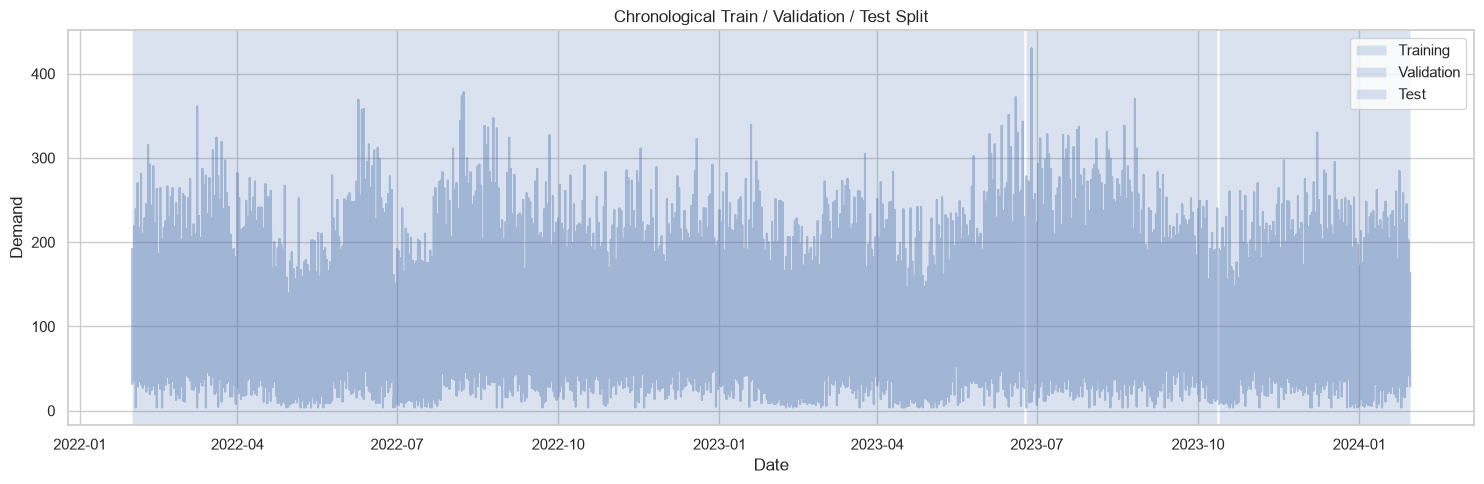

In [36]:
plt.figure(figsize=(15, 5))

plt.axvspan(
    train_df["Date"].min(),
    train_df["Date"].max(),
    alpha=0.2,
    label="Training"
)

plt.axvspan(
    validation_df["Date"].min(),
    validation_df["Date"].max(),
    alpha=0.2,
    label="Validation"
)

plt.axvspan(
    test_df["Date"].min(),
    test_df["Date"].max(),
    alpha=0.2,
    label="Test"
)

plt.plot(
    model_df["Date"],
    model_df["Demand"],
    alpha=0.4
)

plt.title("Chronological Train / Validation / Test Split")
plt.xlabel("Date")
plt.ylabel("Demand")

plt.legend()

plt.tight_layout()
plt.show()

## 14. Save ML Datasets

The processed datasets will be stored separately so that the machine learning
notebook can load them without repeating feature engineering.

In [37]:
import os

os.makedirs(
    "../data/processed",
    exist_ok=True
)

train_path = "../data/processed/train.csv"
validation_path = "../data/processed/validation.csv"
test_path = "../data/processed/test.csv"
features_path = "../data/processed/model_dataset.csv"

train_df.to_csv(
    train_path,
    index=False
)

validation_df.to_csv(
    validation_path,
    index=False
)

test_df.to_csv(
    test_path,
    index=False
)

model_df.to_csv(
    features_path,
    index=False
)

print("ML datasets saved successfully.")

ML datasets saved successfully.


In [38]:
feature_summary = pd.DataFrame({
    "Feature": model_features,
    "Data Type": [
        model_df[feature].dtype
        for feature in model_features
    ],
    "Missing Values": [
        model_df[feature].isna().sum()
        for feature in model_features
    ],
    "Unique Values": [
        model_df[feature].nunique()
        for feature in model_features
    ]
})

feature_summary

,Feature,Data Type,Missing Values,Unique Values
0,Year,int32,0,3
1,Month,int32,0,12
2,Quarter,int32,0,4
3,DayOfMonth,int32,0,31
4,DayOfWeek,int32,0,7
5,WeekOfYear,int64,0,52
6,IsWeekend,int64,0,2
7,DayOfWeek_Sin,float64,0,7
8,DayOfWeek_Cos,float64,0,7
9,Month_Sin,float64,0,11


In [39]:
print("FINAL ML DATASET VALIDATION")
print("=" * 60)

print(f"Full dataset rows : {len(model_df):,}")
print(f"Training rows     : {len(train_df):,}")
print(f"Validation rows   : {len(validation_df):,}")
print(f"Testing rows      : {len(test_df):,}")

print(
    f"\nTraining dates:"
    f" {train_df['Date'].min().date()}"
    f" → {train_df['Date'].max().date()}"
)

print(
    f"Validation dates:"
    f" {validation_df['Date'].min().date()}"
    f" → {validation_df['Date'].max().date()}"
)

print(
    f"Testing dates:"
    f" {test_df['Date'].min().date()}"
    f" → {test_df['Date'].max().date()}"
)

print(
    f"\nMissing values in train:"
    f" {train_df.isna().sum().sum():,}"
)

print(
    f"Missing values in validation:"
    f" {validation_df.isna().sum().sum():,}"
)

print(
    f"Missing values in test:"
    f" {test_df.isna().sum().sum():,}"
)

FINAL ML DATASET VALIDATION
Full dataset rows : 73,000
Training rows     : 51,000
Validation rows   : 11,000
Testing rows      : 11,000

Training dates: 2022-01-31 → 2023-06-24
Validation dates: 2023-06-25 → 2023-10-12
Testing dates: 2023-10-13 → 2024-01-30

Missing values in train: 0
Missing values in validation: 0
Missing values in test: 0


# 15. Conclusion

The cleaned retail dataset has been transformed into a supervised-learning
dataset suitable for demand forecasting.

### Features created

The feature engineering process introduced:

- Calendar features
- Cyclical calendar features
- Historical demand lags
- Rolling demand statistics
- Historical inventory features
- Historical sales features
- Historical order features
- Price-change features
- Competitor pricing features
- Inventory-demand indicators
- Store/product/category/region information

### Leakage Prevention

Historical demand, sales, orders, and inventory features were created using
shifted observations.

Current `Units Sold` and current `Units Ordered` were intentionally excluded
from the initial forecasting feature set because they may not be available at
the time a future prediction is generated.

### Data Splitting

The dataset was divided chronologically into:

- Training set
- Validation set
- Test set

No random train/test split was used.

### Output Files

The following datasets were generated:

- `data/processed/model_dataset.csv`
- `data/processed/train.csv`
- `data/processed/validation.csv`
- `data/processed/test.csv`

### Next Step

The next notebook will develop and compare machine learning models.

## Notebook 05 — Model Training and Evaluation

Candidate models will include:

1. Naive/seasonal baseline
2. Linear/regularized regression baseline
3. Random Forest
4. XGBoost

Models will be evaluated using appropriate forecasting metrics such as:

- MAE
- RMSE
- MAPE / sMAPE
- R²

The final model will be selected based on validation performance and
generalization to the unseen test period.